<a href="https://colab.research.google.com/github/AfrinHossai/cs171-police-call-forecasting/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

processed_folder = (
    "/content/drive/MyDrive/"
    "CS171_Police_Call_Project/data_processed"
)

model_ready_path = os.path.join(
    processed_folder,
    "model_ready_hourly.csv"
)

eda_df = pd.read_csv(
    model_ready_path,
    parse_dates=["HOUR", "NEXT_TIMESTAMP"]
)

print("Dataset shape:", eda_df.shape)
print("\nColumns:")
print(eda_df.columns.tolist())

print("\nSplit counts:")
print(eda_df["SPLIT"].value_counts())

print("\nTimestamp range:")
print("Start:", eda_df["NEXT_TIMESTAMP"].min())
print("End:", eda_df["NEXT_TIMESTAMP"].max())

print("\nMissing values:", eda_df.isna().sum().sum())

display(eda_df.head())

Dataset shape: (21236, 52)

Columns:
['HOUR', 'NEXT_TIMESTAMP', 'SPLIT', 'TARGET_HOUR', 'TARGET_DAY_OF_WEEK', 'TARGET_MONTH', 'TARGET_IS_WEEKEND', 'HOUR_SIN', 'HOUR_COS', 'DAY_OF_WEEK_SIN', 'DAY_OF_WEEK_COS', 'MONTH_SIN', 'MONTH_COS', 'LAG_1H', 'LAG_2H', 'LAG_3H', 'LAG_24H', 'LAG_48H', 'LAG_168H', 'ROLLING_MEAN_3H', 'ROLLING_MEAN_6H', 'ROLLING_MEAN_24H', 'ROLLING_MEAN_168H', 'CURRENT_PRIORITY_1_COUNT', 'CURRENT_PRIORITY_2_COUNT', 'CURRENT_PRIORITY_3_COUNT', 'CURRENT_PRIORITY_4_COUNT', 'CURRENT_PRIORITY_5_COUNT', 'CURRENT_PRIORITY_6_COUNT', 'CURRENT_PRIORITY_OTHER_COUNT', 'CURRENT_CALLTYPE_VEHICLE_STOP_COUNT', 'CURRENT_CALLTYPE_DISTURBANCE_COUNT', 'CURRENT_CALLTYPE_WELFARE_CHECK_COUNT', 'CURRENT_CALLTYPE_ALARM_AUDIBLE_COUNT', 'CURRENT_CALLTYPE_PARKING_VIOLATION_COUNT', 'CURRENT_CALLTYPE_DISTURBANCE_MUSIC_COUNT', 'CURRENT_CALLTYPE_DISTURBANCE_FAMILY_COUNT', 'CURRENT_CALLTYPE_SUSPICIOUS_PERSON_COUNT', 'CURRENT_CALLTYPE_TRESPASSING_COUNT', 'CURRENT_CALLTYPE_SUSPICIOUS_VEHICLE_COUNT', 'CURR

,HOUR,NEXT_TIMESTAMP,SPLIT,TARGET_HOUR,TARGET_DAY_OF_WEEK,TARGET_MONTH,TARGET_IS_WEEKEND,HOUR_SIN,HOUR_COS,DAY_OF_WEEK_SIN,...,CURRENT_CALLTYPE_SUSPICIOUS_CIRCUMSTANCES_COUNT,CURRENT_CALLTYPE_THEFT_COUNT,CURRENT_CALLTYPE_RECKLESS_DRIVING_COUNT,CURRENT_CALLTYPE_VEHICLE_ACCIDENT_PROPERTY_DAMAGE_COUNT,CURRENT_CALLTYPE_PEDESTRIAN_STOP_COUNT,CURRENT_CALLTYPE_TRAFFIC_HAZARD_COUNT,CURRENT_CALLTYPE_MEET_THE_CITIZEN_COUNT,CURRENT_CALLTYPE_RECOVERED_STOLEN_VEHICLE_COUNT,CURRENT_CALLTYPE_OTHER_COUNT,NEXT_HOUR_CALLS
0,2024-01-07 23:00:00,2024-01-08 00:00:00,train,0,0,1,0,0.000000,1.000000,0.0,...,0,0,1,1,1,0,0,2,4,34
1,2024-01-08 00:00:00,2024-01-08 01:00:00,train,1,0,1,0,0.258819,0.965926,0.0,...,0,0,2,0,1,0,0,0,5,21
2,2024-01-08 01:00:00,2024-01-08 02:00:00,train,2,0,1,0,0.500000,0.866025,0.0,...,0,0,1,0,1,0,0,0,2,19
3,2024-01-08 02:00:00,2024-01-08 03:00:00,train,3,0,1,0,0.707107,0.707107,0.0,...,0,0,0,0,0,1,0,2,5,12
4,2024-01-08 03:00:00,2024-01-08 04:00:00,train,4,0,1,0,0.866025,0.500000,0.0,...,1,0,0,0,1,0,0,0,2,16


,Statistic,Value
0,Count,21236.000000
1,Mean,30.471558
2,Median,31.000000
3,Standard deviation,12.463806
4,Minimum,2.000000
5,25th percentile,22.000000
6,75th percentile,38.000000
7,95th percentile,50.000000
8,99th percentile,66.000000
9,Maximum,166.000000


High-volume threshold (95th percentile): 50.0
Hours at or above the threshold: 1139
Percentage of high-volume hours: 5.36 %


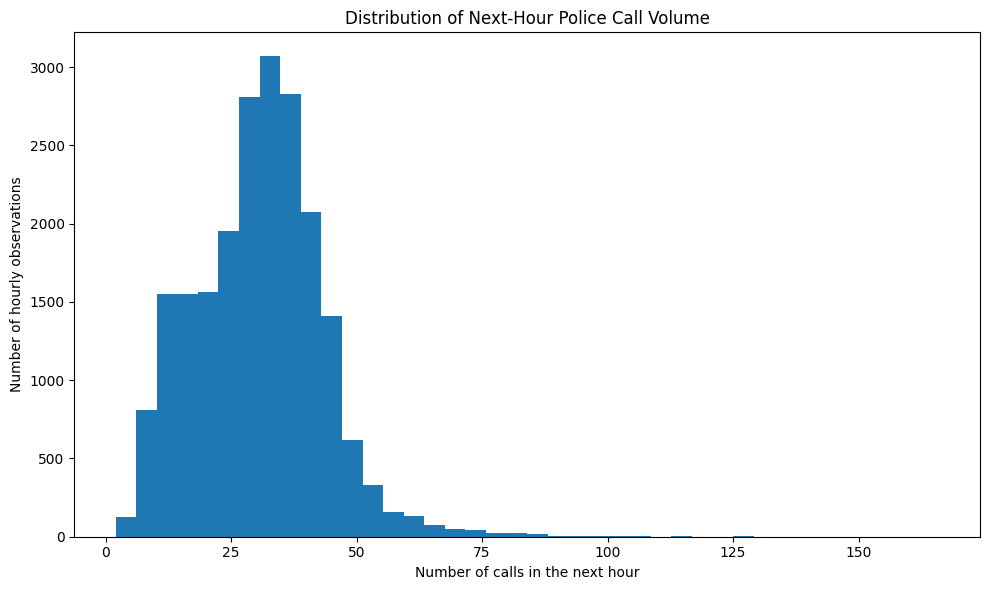

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/target_distribution.png
Figure exists: True


In [3]:
figures_folder = (
    "/content/drive/MyDrive/"
    "CS171_Police_Call_Project/figures"
)

os.makedirs(figures_folder, exist_ok=True)

target = eda_df["NEXT_HOUR_CALLS"]

target_summary = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Standard deviation",
        "Minimum",
        "25th percentile",
        "75th percentile",
        "95th percentile",
        "99th percentile",
        "Maximum",
        "Skewness"
    ],
    "Value": [
        target.count(),
        target.mean(),
        target.median(),
        target.std(),
        target.min(),
        target.quantile(0.25),
        target.quantile(0.75),
        target.quantile(0.95),
        target.quantile(0.99),
        target.max(),
        target.skew()
    ]
})

display(target_summary)

high_volume_threshold = target.quantile(0.95)

print(
    "High-volume threshold (95th percentile):",
    high_volume_threshold
)

print(
    "Hours at or above the threshold:",
    (target >= high_volume_threshold).sum()
)

print(
    "Percentage of high-volume hours:",
    round(
        (target >= high_volume_threshold).mean() * 100,
        2
    ),
    "%"
)

plt.figure(figsize=(10, 6))

plt.hist(
    target,
    bins=40
)

plt.title(
    "Distribution of Next-Hour Police Call Volume"
)

plt.xlabel(
    "Number of calls in the next hour"
)

plt.ylabel(
    "Number of hourly observations"
)

plt.tight_layout()

target_distribution_path = os.path.join(
    figures_folder,
    "target_distribution.png"
)

plt.savefig(
    target_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    target_distribution_path
)

print(
    "Figure exists:",
    os.path.exists(target_distribution_path)
)

,TARGET_HOUR,mean_calls,median_calls,standard_deviation,observations
0,0,32.650847,30.0,12.389015,885
1,1,26.230508,24.0,10.379179,885
2,2,22.000000,20.0,8.676557,882
3,3,16.788701,16.0,6.387867,885
4,4,13.469457,13.0,4.746123,884
5,5,12.550282,12.0,4.004665,885
6,6,13.438418,13.0,4.360701,885
7,7,21.270056,21.0,5.966958,885
8,8,28.142373,28.0,7.266584,885
9,9,30.402260,30.0,6.795227,885


Highest average-volume hour: 22 with 43.11 calls
Lowest average-volume hour: 5 with 12.55 calls


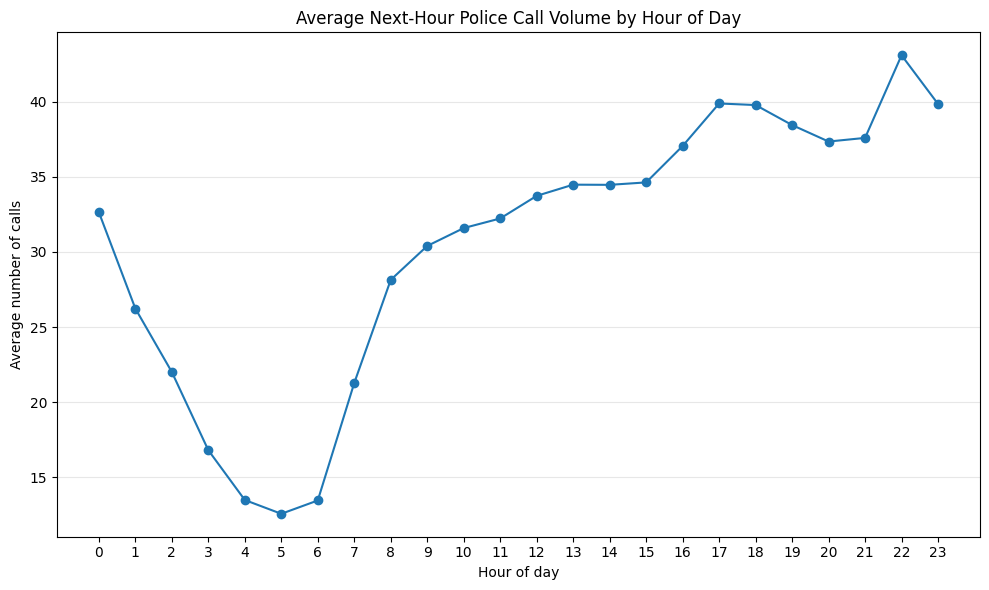

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/average_calls_by_hour.png
Figure exists: True


In [4]:
hourly_pattern = (
    eda_df
    .groupby("TARGET_HOUR")["NEXT_HOUR_CALLS"]
    .agg(
        mean_calls="mean",
        median_calls="median",
        standard_deviation="std",
        observations="count"
    )
    .reset_index()
)

display(hourly_pattern)

highest_hour_row = hourly_pattern.loc[
    hourly_pattern["mean_calls"].idxmax()
]

lowest_hour_row = hourly_pattern.loc[
    hourly_pattern["mean_calls"].idxmin()
]

print(
    "Highest average-volume hour:",
    int(highest_hour_row["TARGET_HOUR"]),
    "with",
    round(highest_hour_row["mean_calls"], 2),
    "calls"
)

print(
    "Lowest average-volume hour:",
    int(lowest_hour_row["TARGET_HOUR"]),
    "with",
    round(lowest_hour_row["mean_calls"], 2),
    "calls"
)

plt.figure(figsize=(10, 6))

plt.plot(
    hourly_pattern["TARGET_HOUR"],
    hourly_pattern["mean_calls"],
    marker="o"
)

plt.xticks(range(24))

plt.title(
    "Average Next-Hour Police Call Volume by Hour of Day"
)

plt.xlabel("Hour of day")

plt.ylabel("Average number of calls")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

hourly_pattern_path = os.path.join(
    figures_folder,
    "average_calls_by_hour.png"
)

plt.savefig(
    hourly_pattern_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", hourly_pattern_path)
print("Figure exists:", os.path.exists(hourly_pattern_path))

,TARGET_DAY_OF_WEEK,DAY_NAME,mean_calls,median_calls,standard_deviation,observations
0,0,Monday,29.512139,30.0,10.810046,3048
1,1,Tuesday,28.799803,30.0,11.093051,3047
2,2,Wednesday,28.712270,30.0,10.899196,3048
3,3,Thursday,29.286706,31.0,11.319532,3024
4,4,Friday,31.728505,32.0,13.457104,3024
5,5,Saturday,33.652778,32.0,15.276040,3024
6,6,Sunday,31.644158,31.0,12.882126,3021


Highest average-volume day: Saturday with 33.65 calls per hour
Lowest average-volume day: Wednesday with 28.71 calls per hour


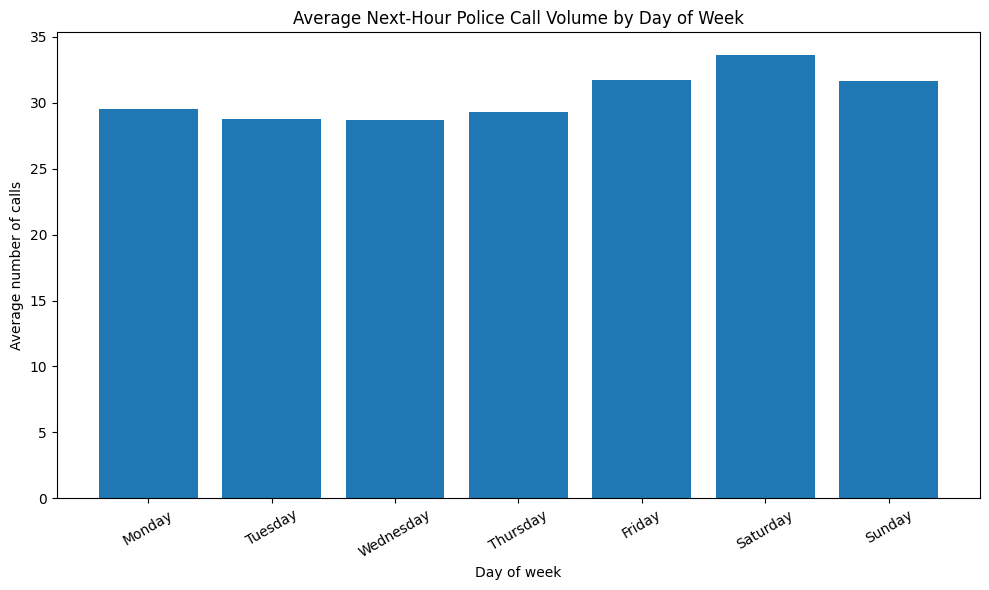

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/average_calls_by_weekday.png
Figure exists: True


In [5]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

weekday_pattern = (
    eda_df
    .groupby("TARGET_DAY_OF_WEEK")["NEXT_HOUR_CALLS"]
    .agg(
        mean_calls="mean",
        median_calls="median",
        standard_deviation="std",
        observations="count"
    )
    .reset_index()
)

weekday_pattern["DAY_NAME"] = (
    weekday_pattern["TARGET_DAY_OF_WEEK"]
    .map(day_names)
)

weekday_pattern = weekday_pattern[
    [
        "TARGET_DAY_OF_WEEK",
        "DAY_NAME",
        "mean_calls",
        "median_calls",
        "standard_deviation",
        "observations"
    ]
]

display(weekday_pattern)

highest_day = weekday_pattern.loc[
    weekday_pattern["mean_calls"].idxmax()
]

lowest_day = weekday_pattern.loc[
    weekday_pattern["mean_calls"].idxmin()
]

print(
    "Highest average-volume day:",
    highest_day["DAY_NAME"],
    "with",
    round(highest_day["mean_calls"], 2),
    "calls per hour"
)

print(
    "Lowest average-volume day:",
    lowest_day["DAY_NAME"],
    "with",
    round(lowest_day["mean_calls"], 2),
    "calls per hour"
)

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_pattern["DAY_NAME"],
    weekday_pattern["mean_calls"]
)

plt.title(
    "Average Next-Hour Police Call Volume by Day of Week"
)

plt.xlabel("Day of week")
plt.ylabel("Average number of calls")

plt.xticks(rotation=30)

plt.tight_layout()

weekday_pattern_path = os.path.join(
    figures_folder,
    "average_calls_by_weekday.png"
)

plt.savefig(
    weekday_pattern_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", weekday_pattern_path)
print("Figure exists:", os.path.exists(weekday_pattern_path))

Average calls by weekday and hour:


TARGET_HOUR,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Monday,32.55,25.58,21.03,15.88,12.15,12.98,14.01,22.55,28.96,30.28,...,34.94,35.54,37.43,38.91,40.12,36.64,34.56,33.65,34.17,32.24
Tuesday,25.94,19.76,16.16,13.60,11.78,12.50,13.81,23.42,30.61,32.57,...,35.28,34.61,36.68,40.84,39.11,36.83,33.09,33.15,34.17,30.65
Wednesday,25.13,19.54,16.72,14.45,12.57,12.27,13.80,23.53,31.84,32.86,...,36.45,35.26,34.50,38.46,37.17,35.50,34.12,31.72,34.66,30.14
Thursday,25.15,20.41,16.98,14.31,12.81,12.10,14.00,21.71,31.01,32.09,...,34.79,34.40,36.15,40.01,39.96,37.38,35.05,35.02,39.10,34.76
Friday,29.23,23.32,20.06,15.21,12.62,11.78,13.33,21.84,29.10,31.27,...,35.73,35.96,38.84,42.11,42.01,41.21,40.85,42.37,51.33,49.94
Saturday,41.86,34.39,30.21,21.30,16.09,13.49,12.68,18.79,23.74,27.64,...,32.90,33.78,37.99,40.64,40.90,42.67,45.13,47.61,62.17,59.92
Sunday,48.81,40.72,33.20,22.82,16.29,12.75,12.44,17.02,21.68,26.07,...,31.21,32.90,37.88,38.33,39.31,39.03,38.82,39.81,46.40,41.61



Highest average combination: Saturday at 22:00, 62.17 calls
Lowest average combination: Tuesday at 4:00, 11.78 calls


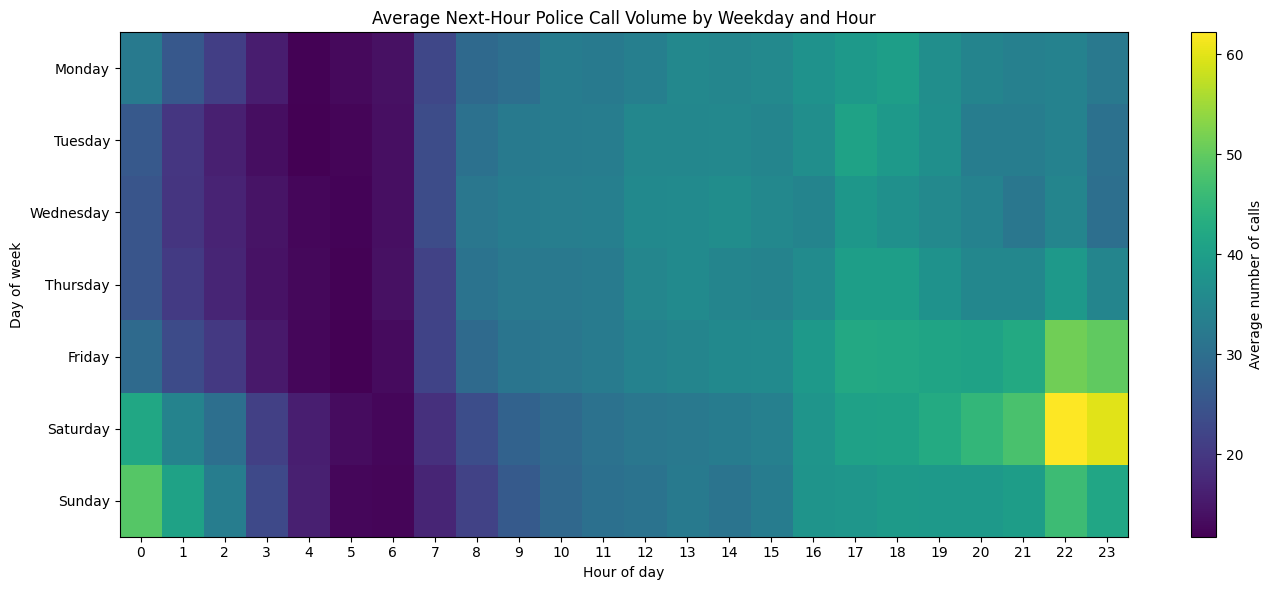

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/weekday_hour_heatmap.png
Figure exists: True


In [6]:
weekday_hour_matrix = eda_df.pivot_table(
    index="TARGET_DAY_OF_WEEK",
    columns="TARGET_HOUR",
    values="NEXT_HOUR_CALLS",
    aggfunc="mean"
)

weekday_hour_matrix = weekday_hour_matrix.reindex(
    index=range(7),
    columns=range(24)
)

weekday_hour_matrix.index = [
    day_names[day]
    for day in weekday_hour_matrix.index
]

print("Average calls by weekday and hour:")
display(weekday_hour_matrix.round(2))

maximum_location = np.unravel_index(
    np.nanargmax(weekday_hour_matrix.to_numpy()),
    weekday_hour_matrix.shape
)

minimum_location = np.unravel_index(
    np.nanargmin(weekday_hour_matrix.to_numpy()),
    weekday_hour_matrix.shape
)

highest_day_name = weekday_hour_matrix.index[
    maximum_location[0]
]

highest_hour = weekday_hour_matrix.columns[
    maximum_location[1]
]

highest_value = weekday_hour_matrix.iloc[
    maximum_location
]

lowest_day_name = weekday_hour_matrix.index[
    minimum_location[0]
]

lowest_hour = weekday_hour_matrix.columns[
    minimum_location[1]
]

lowest_value = weekday_hour_matrix.iloc[
    minimum_location
]

print(
    "\nHighest average combination:",
    highest_day_name,
    f"at {highest_hour}:00,",
    round(highest_value, 2),
    "calls"
)

print(
    "Lowest average combination:",
    lowest_day_name,
    f"at {lowest_hour}:00,",
    round(lowest_value, 2),
    "calls"
)

plt.figure(figsize=(14, 6))

heatmap = plt.imshow(
    weekday_hour_matrix,
    aspect="auto"
)

plt.colorbar(
    heatmap,
    label="Average number of calls"
)

plt.title(
    "Average Next-Hour Police Call Volume by Weekday and Hour"
)

plt.xlabel("Hour of day")
plt.ylabel("Day of week")

plt.xticks(
    ticks=range(24),
    labels=range(24)
)

plt.yticks(
    ticks=range(7),
    labels=weekday_hour_matrix.index
)

plt.tight_layout()

heatmap_path = os.path.join(
    figures_folder,
    "weekday_hour_heatmap.png"
)

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", heatmap_path)
print("Figure exists:", os.path.exists(heatmap_path))

In [8]:
eda_df["SOURCE_YEAR"] = eda_df["HOUR"].dt.year

print(eda_df["SOURCE_YEAR"].value_counts().sort_index())

SOURCE_YEAR
2024    8448
2025    8591
2026    4197
Name: count, dtype: int64


Year-by-year target summary:


,SOURCE_YEAR,mean_calls,median_calls,standard_deviation,minimum,maximum,observations
0,2024,31.07,32.0,12.17,2,101,8448
1,2025,29.92,30.0,11.90,2,100,8591
2,2026,30.39,30.0,14.03,4,166,4197



Highest average year: 2024
Lowest average year: 2025


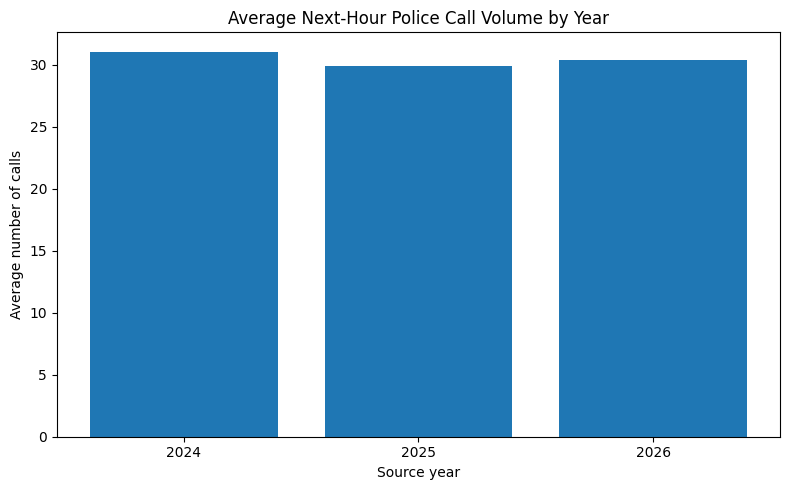

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/average_calls_by_year.png
Figure exists: True


In [9]:
yearly_summary = (
    eda_df.groupby("SOURCE_YEAR")["NEXT_HOUR_CALLS"]
    .agg(
        mean_calls="mean",
        median_calls="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
        observations="count"
    )
    .reset_index()
)

print("Year-by-year target summary:")
display(yearly_summary.round(2))

highest_year = yearly_summary.loc[
    yearly_summary["mean_calls"].idxmax(),
    "SOURCE_YEAR"
]

lowest_year = yearly_summary.loc[
    yearly_summary["mean_calls"].idxmin(),
    "SOURCE_YEAR"
]

print("\nHighest average year:", highest_year)
print("Lowest average year:", lowest_year)

plt.figure(figsize=(8, 5))
plt.bar(
    yearly_summary["SOURCE_YEAR"].astype(str),
    yearly_summary["mean_calls"]
)

plt.title("Average Next-Hour Police Call Volume by Year")
plt.xlabel("Source year")
plt.ylabel("Average number of calls")

plt.tight_layout()

year_comparison_path = os.path.join(
    figures_folder,
    "average_calls_by_year.png"
)

plt.savefig(
    year_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", year_comparison_path)
print("Figure exists:", os.path.exists(year_comparison_path))

January 8–July 8 comparison:


,SOURCE_YEAR,mean_calls,median_calls,standard_deviation,minimum,maximum,observations
0,2024,30.94,32.0,12.34,3,99,4223
1,2025,30.25,31.0,12.20,4,100,4199
2,2026,30.51,30.0,14.14,4,166,4030



Highest same-period average: 2024
Lowest same-period average: 2025


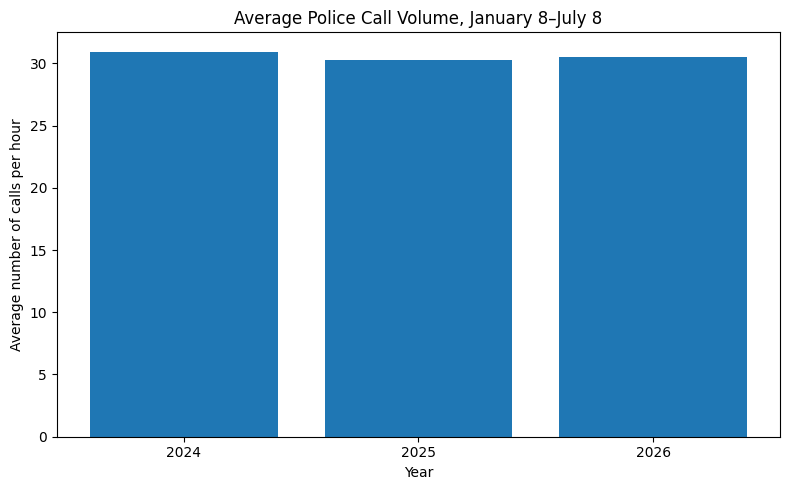

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/same_period_year_comparison.png
Figure exists: True


In [10]:
# Compare the same calendar period across 2024, 2025, and 2026
month = eda_df["NEXT_TIMESTAMP"].dt.month
day = eda_df["NEXT_TIMESTAMP"].dt.day

same_period_mask = (
    ((month > 1) | ((month == 1) & (day >= 8)))
    &
    ((month < 7) | ((month == 7) & (day <= 8)))
)

same_period_df = eda_df.loc[same_period_mask].copy()

same_period_summary = (
    same_period_df
    .groupby("SOURCE_YEAR")["NEXT_HOUR_CALLS"]
    .agg(
        mean_calls="mean",
        median_calls="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
        observations="count"
    )
    .reset_index()
)

print("January 8–July 8 comparison:")
display(same_period_summary.round(2))

highest_same_period_year = same_period_summary.loc[
    same_period_summary["mean_calls"].idxmax(),
    "SOURCE_YEAR"
]

lowest_same_period_year = same_period_summary.loc[
    same_period_summary["mean_calls"].idxmin(),
    "SOURCE_YEAR"
]

print("\nHighest same-period average:", highest_same_period_year)
print("Lowest same-period average:", lowest_same_period_year)

plt.figure(figsize=(8, 5))

plt.bar(
    same_period_summary["SOURCE_YEAR"].astype(str),
    same_period_summary["mean_calls"]
)

plt.title(
    "Average Police Call Volume, January 8–July 8"
)

plt.xlabel("Year")
plt.ylabel("Average number of calls per hour")

plt.tight_layout()

same_period_path = os.path.join(
    figures_folder,
    "same_period_year_comparison.png"
)

plt.savefig(
    same_period_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", same_period_path)
print("Figure exists:", os.path.exists(same_period_path))

Overall priority distribution:


,PRIORITY,TOTAL_INCIDENTS,PERCENT
0,Priority 1,20244,3.13
1,Priority 2,191626,29.62
2,Priority 3,238911,36.92
3,Priority 4,74566,11.52
4,Priority 5,43493,6.72
5,Priority 6,78193,12.08
6,Other,2,0.00


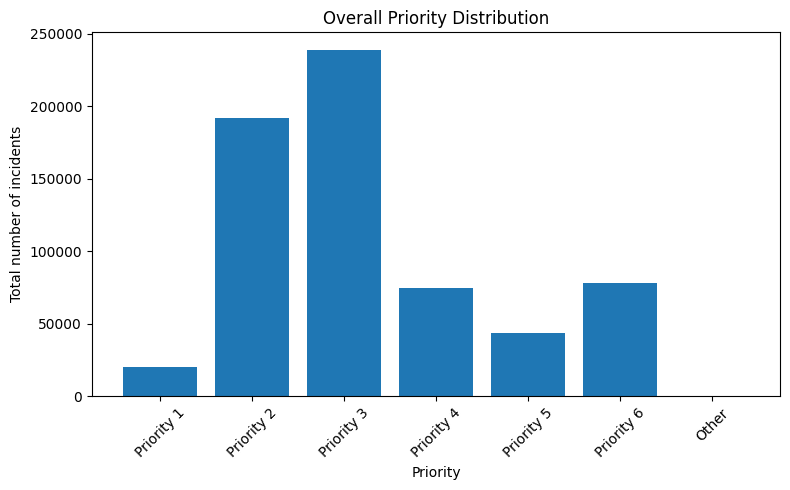

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/priority_distribution.png
Figure exists: True


In [11]:
priority_columns = [
    "CURRENT_PRIORITY_1_COUNT",
    "CURRENT_PRIORITY_2_COUNT",
    "CURRENT_PRIORITY_3_COUNT",
    "CURRENT_PRIORITY_4_COUNT",
    "CURRENT_PRIORITY_5_COUNT",
    "CURRENT_PRIORITY_6_COUNT",
    "CURRENT_PRIORITY_OTHER_COUNT"
]

priority_labels = [
    "Priority 1",
    "Priority 2",
    "Priority 3",
    "Priority 4",
    "Priority 5",
    "Priority 6",
    "Other"
]

priority_totals = eda_df[priority_columns].sum()

priority_summary = pd.DataFrame({
    "PRIORITY": priority_labels,
    "TOTAL_INCIDENTS": priority_totals.values
})

priority_summary["PERCENT"] = (
    priority_summary["TOTAL_INCIDENTS"] /
    priority_summary["TOTAL_INCIDENTS"].sum() * 100
)

print("Overall priority distribution:")
display(priority_summary.round(2))

plt.figure(figsize=(8, 5))
plt.bar(priority_summary["PRIORITY"], priority_summary["TOTAL_INCIDENTS"])
plt.title("Overall Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Total number of incidents")
plt.xticks(rotation=45)
plt.tight_layout()

priority_distribution_path = os.path.join(
    figures_folder,
    "priority_distribution.png"
)

plt.savefig(priority_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", priority_distribution_path)
print("Figure exists:", os.path.exists(priority_distribution_path))

Numerical feature relationships with NEXT_HOUR_CALLS:


,FEATURE,PEARSON_CORRELATION,SPEARMAN_CORRELATION
0,LAG_1H,0.731,0.704
1,LAG_168H,0.724,0.708
2,LAG_24H,0.672,0.659
3,ROLLING_MEAN_3H,0.651,0.638
4,LAG_2H,0.587,0.581
5,LAG_48H,0.561,0.575
6,ROLLING_MEAN_6H,0.424,0.421
7,LAG_3H,0.417,0.423
8,ROLLING_MEAN_24H,0.138,0.121
9,ROLLING_MEAN_168H,0.085,0.083



Strongest numerical relationship: LAG_1H with Pearson correlation 0.731


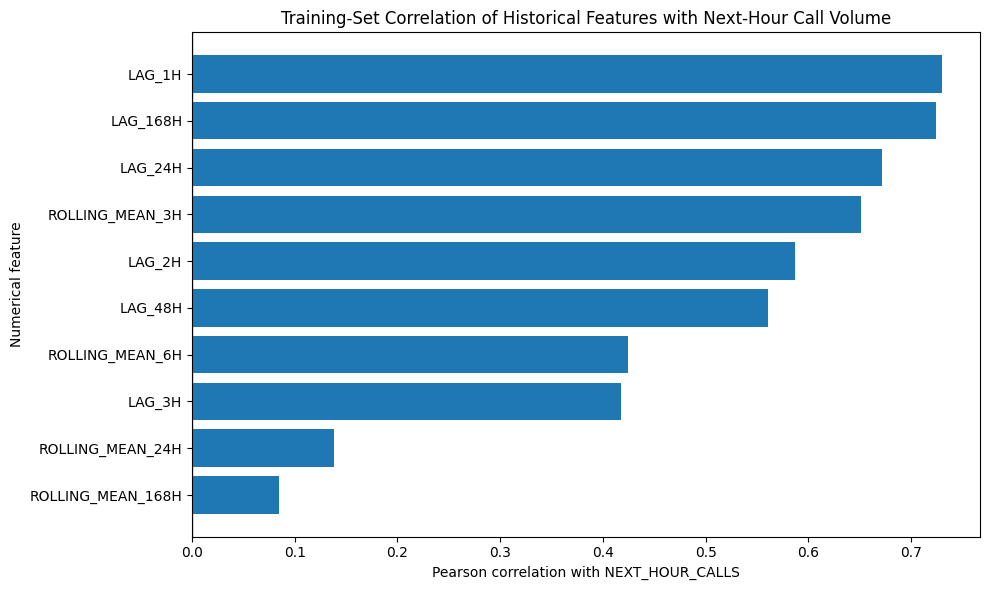

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/numerical_feature_correlations.png
Figure exists: True


In [12]:
training_eda_df = eda_df.loc[
    eda_df["SPLIT"] == "train"
].copy()

important_numerical_features = [
    "LAG_1H",
    "LAG_2H",
    "LAG_3H",
    "LAG_24H",
    "LAG_48H",
    "LAG_168H",
    "ROLLING_MEAN_3H",
    "ROLLING_MEAN_6H",
    "ROLLING_MEAN_24H",
    "ROLLING_MEAN_168H"
]

numerical_correlation_summary = pd.DataFrame({
    "FEATURE": important_numerical_features,
    "PEARSON_CORRELATION": [
        training_eda_df[feature].corr(
            training_eda_df["NEXT_HOUR_CALLS"],
            method="pearson"
        )
        for feature in important_numerical_features
    ],
    "SPEARMAN_CORRELATION": [
        training_eda_df[feature].corr(
            training_eda_df["NEXT_HOUR_CALLS"],
            method="spearman"
        )
        for feature in important_numerical_features
    ]
})

numerical_correlation_summary["ABS_PEARSON"] = (
    numerical_correlation_summary["PEARSON_CORRELATION"].abs()
)

numerical_correlation_summary = (
    numerical_correlation_summary
    .sort_values("ABS_PEARSON", ascending=False)
    .reset_index(drop=True)
)

print("Numerical feature relationships with NEXT_HOUR_CALLS:")
display(
    numerical_correlation_summary[
        [
            "FEATURE",
            "PEARSON_CORRELATION",
            "SPEARMAN_CORRELATION"
        ]
    ].round(3)
)

strongest_feature = numerical_correlation_summary.iloc[0]

print(
    "\nStrongest numerical relationship:",
    strongest_feature["FEATURE"],
    "with Pearson correlation",
    round(strongest_feature["PEARSON_CORRELATION"], 3)
)

plot_data = numerical_correlation_summary.sort_values(
    "PEARSON_CORRELATION"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["FEATURE"],
    plot_data["PEARSON_CORRELATION"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "Training-Set Correlation of Historical Features "
    "with Next-Hour Call Volume"
)

plt.xlabel("Pearson correlation with NEXT_HOUR_CALLS")
plt.ylabel("Numerical feature")

plt.tight_layout()

numerical_correlation_path = os.path.join(
    figures_folder,
    "numerical_feature_correlations.png"
)

plt.savefig(
    numerical_correlation_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", numerical_correlation_path)
print("Figure exists:", os.path.exists(numerical_correlation_path))

Call-type distribution:


,CALL_TYPE,TOTAL_INCIDENTS,PERCENT
0,Other,166942,25.80
1,Vehicle Stop,65089,10.06
2,Disturbance,60670,9.38
3,Welfare Check,51254,7.92
4,Alarm Audible,46678,7.21
5,Parking Violation,29588,4.57
6,Disturbance Music,22124,3.42
7,Disturbance Family,20860,3.22
8,Suspicious Person,20605,3.18
9,Trespassing,20066,3.10



Most frequent selected call type: Vehicle Stop


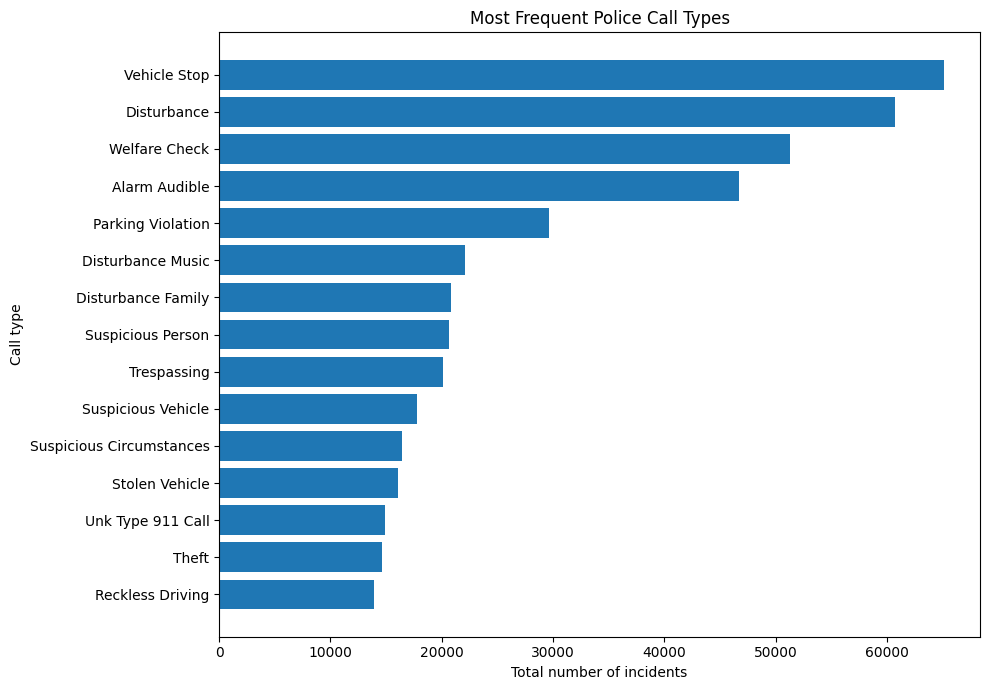

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/top_call_type_distribution.png
Figure exists: True


In [13]:
call_type_columns = [
    column
    for column in eda_df.columns
    if column.startswith("CURRENT_CALLTYPE_")
    and column.endswith("_COUNT")
]

call_type_totals = (
    eda_df[call_type_columns]
    .sum()
    .sort_values(ascending=False)
)

call_type_summary = (
    call_type_totals
    .rename("TOTAL_INCIDENTS")
    .reset_index()
    .rename(columns={"index": "FEATURE"})
)

call_type_summary["CALL_TYPE"] = (
    call_type_summary["FEATURE"]
    .str.replace(
        "CURRENT_CALLTYPE_",
        "",
        regex=False
    )
    .str.replace(
        "_COUNT",
        "",
        regex=False
    )
    .str.replace("_", " ", regex=False)
    .str.title()
)

call_type_summary["PERCENT"] = (
    call_type_summary["TOTAL_INCIDENTS"]
    / call_type_summary["TOTAL_INCIDENTS"].sum()
    * 100
)

print("Call-type distribution:")
display(
    call_type_summary[
        ["CALL_TYPE", "TOTAL_INCIDENTS", "PERCENT"]
    ].round(2)
)

# Exclude the broad OTHER category from the ranking figure
selected_call_type_summary = (
    call_type_summary.loc[
        call_type_summary["CALL_TYPE"] != "Other"
    ]
    .head(15)
    .sort_values("TOTAL_INCIDENTS")
)

print(
    "\nMost frequent selected call type:",
    call_type_summary.loc[
        call_type_summary["CALL_TYPE"] != "Other",
        "CALL_TYPE"
    ].iloc[0]
)

plt.figure(figsize=(10, 7))

plt.barh(
    selected_call_type_summary["CALL_TYPE"],
    selected_call_type_summary["TOTAL_INCIDENTS"]
)

plt.title("Most Frequent Police Call Types")
plt.xlabel("Total number of incidents")
plt.ylabel("Call type")

plt.tight_layout()

call_type_distribution_path = os.path.join(
    figures_folder,
    "top_call_type_distribution.png"
)

plt.savefig(
    call_type_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", call_type_distribution_path)
print(
    "Figure exists:",
    os.path.exists(call_type_distribution_path)
)

Monthly average call volume by year:


,SOURCE_YEAR,TARGET_MONTH,mean_calls,median_calls,observations
0,2024,1,28.99,30.0,577
1,2024,2,30.86,32.0,696
2,2024,3,30.95,32.0,575
3,2024,4,29.61,31.0,720
4,2024,5,32.05,33.0,744
5,2024,6,32.17,32.0,720
6,2024,7,32.54,33.0,744
7,2025,1,28.63,29.0,744
8,2025,2,29.17,30.0,672
9,2025,3,30.50,31.0,575


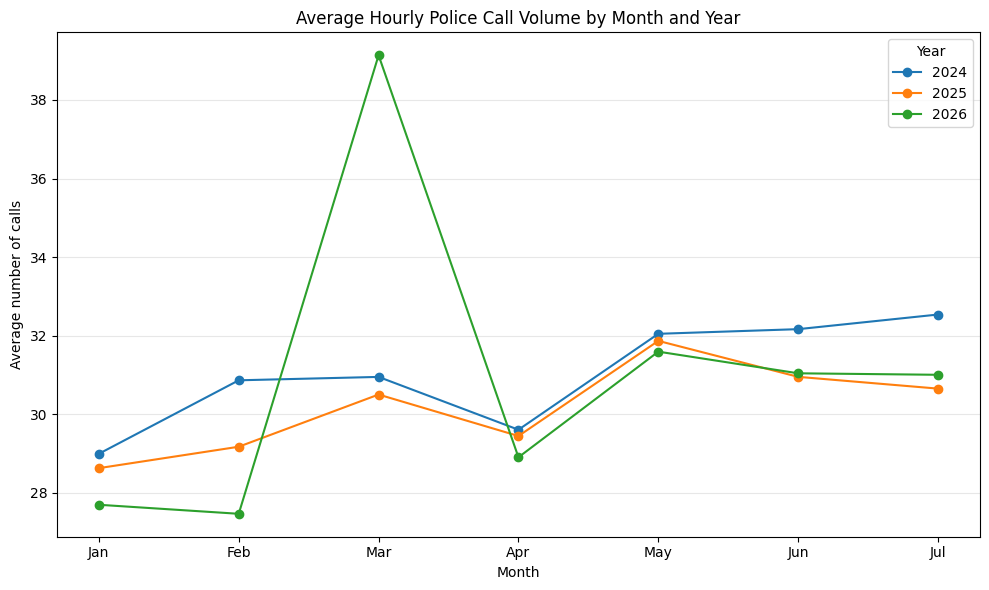

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/monthly_patterns_by_year.png
Figure exists: True


In [14]:
monthly_year_pattern = (
    eda_df.loc[eda_df["TARGET_MONTH"] <= 7]
    .groupby(["SOURCE_YEAR", "TARGET_MONTH"])["NEXT_HOUR_CALLS"]
    .agg(
        mean_calls="mean",
        median_calls="median",
        observations="count"
    )
    .reset_index()
)

print("Monthly average call volume by year:")
display(monthly_year_pattern.round(2))

monthly_pivot = monthly_year_pattern.pivot(
    index="TARGET_MONTH",
    columns="SOURCE_YEAR",
    values="mean_calls"
)

month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul"
}

plt.figure(figsize=(10, 6))

for year in monthly_pivot.columns:
    plt.plot(
        monthly_pivot.index,
        monthly_pivot[year],
        marker="o",
        label=str(year)
    )

plt.title(
    "Average Hourly Police Call Volume by Month and Year"
)

plt.xlabel("Month")
plt.ylabel("Average number of calls")

plt.xticks(
    ticks=range(1, 8),
    labels=[month_names[month] for month in range(1, 8)]
)

plt.legend(title="Year")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

monthly_pattern_path = os.path.join(
    figures_folder,
    "monthly_patterns_by_year.png"
)

plt.savefig(
    monthly_pattern_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", monthly_pattern_path)
print("Figure exists:", os.path.exists(monthly_pattern_path))

In [15]:
monthly_coverage = (
    eda_df
    .groupby(["SOURCE_YEAR", "TARGET_MONTH"])
    .size()
    .reset_index(name="OBSERVED_HOURS")
)

def expected_hours(year, month):
    period_start = max(
        pd.Timestamp(year=year, month=month, day=1),
        pd.Timestamp(year=year, month=1, day=8)
    )

    month_end = (
        pd.Timestamp(year=year, month=month, day=1)
        + pd.offsets.MonthEnd(1)
    ).replace(hour=23)

    period_end = min(
        month_end,
        pd.Timestamp(year=year, month=7, day=8, hour=23)
    )

    if period_start > period_end:
        return 0

    expected = int(
        (period_end - period_start).total_seconds() / 3600
    ) + 1

    # The local 2:00 a.m. hour does not exist on the
    # spring daylight-saving transition date.
    if month == 3:
        expected -= 1

    return expected

monthly_coverage["EXPECTED_HOURS"] = monthly_coverage.apply(
    lambda row: expected_hours(
        int(row["SOURCE_YEAR"]),
        int(row["TARGET_MONTH"])
    ),
    axis=1
)

monthly_coverage["COVERAGE_PERCENT"] = (
    monthly_coverage["OBSERVED_HOURS"]
    / monthly_coverage["EXPECTED_HOURS"]
    * 100
)

monthly_coverage["LOW_COVERAGE_FLAG"] = (
    monthly_coverage["COVERAGE_PERCENT"] < 90
)

print("Monthly observation coverage:")
display(monthly_coverage.round(2))

print("\nMonth-year groups below 90% coverage:")
display(
    monthly_coverage.loc[
        monthly_coverage["LOW_COVERAGE_FLAG"]
    ].round(2)
)

Monthly observation coverage:


,SOURCE_YEAR,TARGET_MONTH,OBSERVED_HOURS,EXPECTED_HOURS,COVERAGE_PERCENT,LOW_COVERAGE_FLAG
0,2024,1,577,576,100.17,False
1,2024,2,696,696,100.00,False
2,2024,3,575,743,77.39,True
3,2024,4,720,720,100.00,False
4,2024,5,744,744,100.00,False
5,2024,6,720,720,100.00,False
6,2024,7,744,192,387.50,False
7,2024,8,744,0,inf,False
8,2024,9,720,0,inf,False
9,2024,10,744,0,inf,False



Month-year groups below 90% coverage:


,SOURCE_YEAR,TARGET_MONTH,OBSERVED_HOURS,EXPECTED_HOURS,COVERAGE_PERCENT,LOW_COVERAGE_FLAG
2,2024,3,575,743,77.39,True
14,2025,3,575,743,77.39,True
26,2026,3,406,743,54.64,True


In [16]:
# Assign each target observation to the year being predicted
eda_df["SOURCE_YEAR"] = eda_df["NEXT_TIMESTAMP"].dt.year

dataset_start = eda_df["NEXT_TIMESTAMP"].min().floor("h")
dataset_end = eda_df["NEXT_TIMESTAMP"].max().floor("h")

dst_missing_hours = {
    2024: pd.Timestamp("2024-03-10 02:00:00"),
    2025: pd.Timestamp("2025-03-09 02:00:00"),
    2026: pd.Timestamp("2026-03-08 02:00:00")
}

monthly_coverage = (
    eda_df
    .groupby(["SOURCE_YEAR", "TARGET_MONTH"])
    .size()
    .reset_index(name="OBSERVED_HOURS")
)

def expected_hours(year, month):
    month_start = pd.Timestamp(
        year=int(year),
        month=int(month),
        day=1,
        hour=0
    )

    month_end = (
        month_start + pd.offsets.MonthEnd(1)
    ).replace(hour=23)

    interval_start = max(month_start, dataset_start)
    interval_end = min(month_end, dataset_end)

    if interval_start > interval_end:
        return 0

    expected = int(
        (interval_end - interval_start).total_seconds() / 3600
    ) + 1

    dst_hour = dst_missing_hours.get(int(year))

    if (
        dst_hour is not None
        and interval_start <= dst_hour <= interval_end
    ):
        expected -= 1

    return expected

monthly_coverage["EXPECTED_HOURS"] = monthly_coverage.apply(
    lambda row: expected_hours(
        row["SOURCE_YEAR"],
        row["TARGET_MONTH"]
    ),
    axis=1
)

monthly_coverage["COVERAGE_PERCENT"] = (
    monthly_coverage["OBSERVED_HOURS"]
    / monthly_coverage["EXPECTED_HOURS"]
    * 100
)

monthly_coverage["LOW_COVERAGE_FLAG"] = (
    monthly_coverage["COVERAGE_PERCENT"] < 90
)

print("Corrected monthly observation coverage:")
display(monthly_coverage.round(2))

print("\nMonth-year groups below 90% coverage:")
display(
    monthly_coverage.loc[
        monthly_coverage["LOW_COVERAGE_FLAG"]
    ].round(2)
)

print("\nInvalid coverage values:")
print(
    "Above 100%:",
    (monthly_coverage["COVERAGE_PERCENT"] > 100.01).sum()
)
print(
    "Infinite:",
    np.isinf(monthly_coverage["COVERAGE_PERCENT"]).sum()
)

Corrected monthly observation coverage:


,SOURCE_YEAR,TARGET_MONTH,OBSERVED_HOURS,EXPECTED_HOURS,COVERAGE_PERCENT,LOW_COVERAGE_FLAG
0,2024,1,576,576,100.00,False
1,2024,2,696,696,100.00,False
2,2024,3,575,743,77.39,True
3,2024,4,720,720,100.00,False
4,2024,5,744,744,100.00,False
5,2024,6,720,720,100.00,False
6,2024,7,744,744,100.00,False
7,2024,8,744,744,100.00,False
8,2024,9,720,720,100.00,False
9,2024,10,744,744,100.00,False



Month-year groups below 90% coverage:


,SOURCE_YEAR,TARGET_MONTH,OBSERVED_HOURS,EXPECTED_HOURS,COVERAGE_PERCENT,LOW_COVERAGE_FLAG
2,2024,3,575,743,77.39,True
14,2025,3,575,743,77.39,True
26,2026,3,406,743,54.64,True



Invalid coverage values:
Above 100%: 0
Infinite: 0


Coverage-qualified monthly comparison:


,SOURCE_YEAR,TARGET_MONTH,mean_calls,median_calls,observations
0,2024,1,28.91,30.0,576
1,2024,2,30.86,32.0,696
2,2024,4,29.61,31.0,720
3,2024,5,32.05,33.0,744
4,2024,6,32.17,32.0,720
5,2024,7,32.54,33.0,744
6,2025,1,28.66,29.0,744
7,2025,2,29.17,30.0,672
8,2025,4,29.45,31.0,720
9,2025,5,31.87,32.0,744


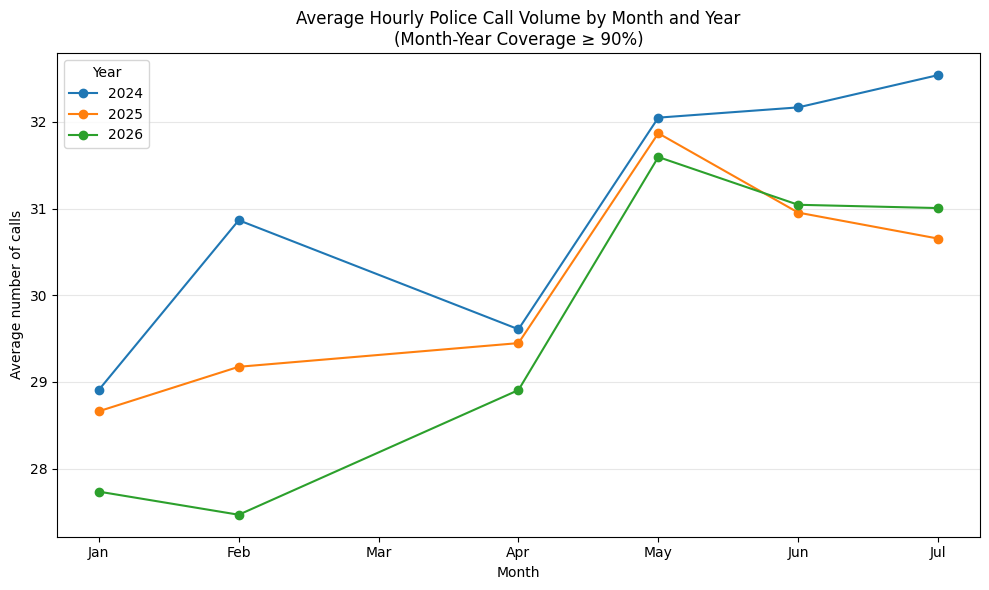

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/monthly_patterns_by_year_qualified.png
Figure exists: True


In [17]:
valid_month_groups = monthly_coverage.loc[
    monthly_coverage["COVERAGE_PERCENT"] >= 90,
    ["SOURCE_YEAR", "TARGET_MONTH"]
]

coverage_qualified_df = eda_df.merge(
    valid_month_groups,
    on=["SOURCE_YEAR", "TARGET_MONTH"],
    how="inner",
    validate="many_to_one"
)

qualified_monthly_pattern = (
    coverage_qualified_df.loc[
        coverage_qualified_df["TARGET_MONTH"] <= 7
    ]
    .groupby(
        ["SOURCE_YEAR", "TARGET_MONTH"]
    )["NEXT_HOUR_CALLS"]
    .agg(
        mean_calls="mean",
        median_calls="median",
        observations="count"
    )
    .reset_index()
)

print("Coverage-qualified monthly comparison:")
display(qualified_monthly_pattern.round(2))

qualified_monthly_pivot = qualified_monthly_pattern.pivot(
    index="TARGET_MONTH",
    columns="SOURCE_YEAR",
    values="mean_calls"
)

plt.figure(figsize=(10, 6))

for year in qualified_monthly_pivot.columns:
    plt.plot(
        qualified_monthly_pivot.index,
        qualified_monthly_pivot[year],
        marker="o",
        label=str(year)
    )

plt.title(
    "Average Hourly Police Call Volume by Month and Year\n"
    "(Month-Year Coverage ≥ 90%)"
)

plt.xlabel("Month")
plt.ylabel("Average number of calls")

plt.xticks(
    ticks=range(1, 8),
    labels=[
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul"
    ]
)

plt.legend(title="Year")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

qualified_monthly_path = os.path.join(
    figures_folder,
    "monthly_patterns_by_year_qualified.png"
)

plt.savefig(
    qualified_monthly_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", qualified_monthly_path)
print(
    "Figure exists:",
    os.path.exists(qualified_monthly_path)
)

High-volume threshold: 50.0
Number of high-volume hours: 1139
Percentage of all hours: 5.36 %

Highest-volume individual hours:


,NEXT_TIMESTAMP,NEXT_HOUR_CALLS,TARGET_HOUR,TARGET_DAY_OF_WEEK,SOURCE_YEAR
18787,2026-03-28 23:00:00,166,23,5,2026
18786,2026-03-28 22:00:00,129,22,5,2026
18784,2026-03-28 20:00:00,125,20,5,2026
18785,2026-03-28 21:00:00,115,21,5,2026
18810,2026-03-29 22:00:00,114,22,6,2026
19621,2026-05-02 17:00:00,106,17,5,2026
21138,2026-07-04 22:00:00,105,22,5,2026
18829,2026-03-30 17:00:00,104,17,0,2026
18853,2026-03-31 17:00:00,101,17,1,2026
18788,2026-03-29 00:00:00,101,0,6,2026



High-volume frequency by hour:


,TARGET_HOUR,high_volume_hours,total_hours,high_volume_rate
0,0,90,885,10.17
1,1,28,885,3.16
2,2,6,882,0.68
3,3,2,885,0.23
4,4,0,884,0.00
5,5,0,885,0.00
6,6,0,885,0.00
7,7,2,885,0.23
8,8,7,885,0.79
9,9,5,885,0.56



Hour with the highest high-volume rate: 22 with 28.47 %


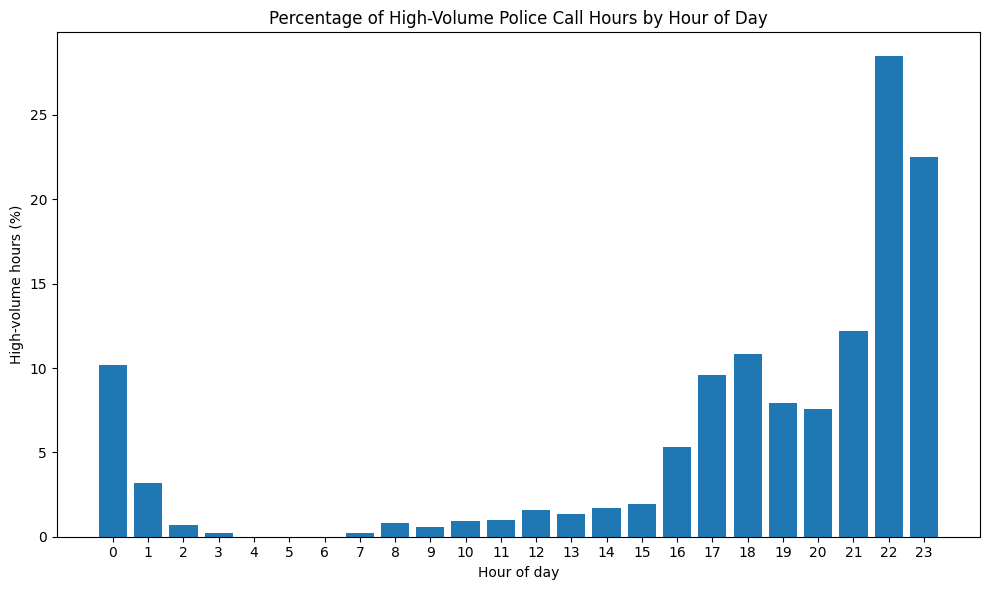

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/high_volume_hours.png
Figure exists: True


In [18]:
high_volume_threshold = eda_df[
    "NEXT_HOUR_CALLS"
].quantile(0.95)

high_volume_df = eda_df.loc[
    eda_df["NEXT_HOUR_CALLS"] >= high_volume_threshold
].copy()

print("High-volume threshold:", high_volume_threshold)
print("Number of high-volume hours:", len(high_volume_df))
print(
    "Percentage of all hours:",
    round(len(high_volume_df) / len(eda_df) * 100, 2),
    "%"
)

print("\nHighest-volume individual hours:")
display(
    high_volume_df[
        [
            "NEXT_TIMESTAMP",
            "NEXT_HOUR_CALLS",
            "TARGET_HOUR",
            "TARGET_DAY_OF_WEEK",
            "SOURCE_YEAR"
        ]
    ]
    .sort_values(
        "NEXT_HOUR_CALLS",
        ascending=False
    )
    .head(15)
)

high_volume_by_hour = (
    eda_df
    .assign(
        HIGH_VOLUME=(
            eda_df["NEXT_HOUR_CALLS"]
            >= high_volume_threshold
        ).astype(int)
    )
    .groupby("TARGET_HOUR")["HIGH_VOLUME"]
    .agg(
        high_volume_hours="sum",
        total_hours="count",
        high_volume_rate="mean"
    )
    .reset_index()
)

high_volume_by_hour["high_volume_rate"] *= 100

print("\nHigh-volume frequency by hour:")
display(high_volume_by_hour.round(2))

peak_high_volume_hour = high_volume_by_hour.loc[
    high_volume_by_hour["high_volume_rate"].idxmax()
]

print(
    "\nHour with the highest high-volume rate:",
    int(peak_high_volume_hour["TARGET_HOUR"]),
    "with",
    round(peak_high_volume_hour["high_volume_rate"], 2),
    "%"
)

plt.figure(figsize=(10, 6))

plt.bar(
    high_volume_by_hour["TARGET_HOUR"],
    high_volume_by_hour["high_volume_rate"]
)

plt.xticks(range(24))

plt.title(
    "Percentage of High-Volume Police Call Hours by Hour of Day"
)

plt.xlabel("Hour of day")
plt.ylabel("High-volume hours (%)")

plt.tight_layout()

high_volume_path = os.path.join(
    figures_folder,
    "high_volume_hours.png"
)

plt.savefig(
    high_volume_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", high_volume_path)
print("Figure exists:", os.path.exists(high_volume_path))

Extreme-volume threshold (99th percentile): 66.0
Number of extreme hours: 222

Top 25 extreme hourly observations:


,NEXT_TIMESTAMP,NEXT_HOUR_CALLS,TARGET_HOUR,TARGET_DAY_OF_WEEK,SOURCE_YEAR
18787,2026-03-28 23:00:00,166,23,5,2026
18786,2026-03-28 22:00:00,129,22,5,2026
18784,2026-03-28 20:00:00,125,20,5,2026
18785,2026-03-28 21:00:00,115,21,5,2026
18810,2026-03-29 22:00:00,114,22,6,2026
19621,2026-05-02 17:00:00,106,17,5,2026
21138,2026-07-04 22:00:00,105,22,5,2026
18829,2026-03-30 17:00:00,104,17,0,2026
6862,2024-10-26 23:00:00,101,23,5,2024
18788,2026-03-29 00:00:00,101,0,6,2026



Dates containing the most extreme hours:


,TARGET_DATE,extreme_hours,maximum_hourly_calls,mean_extreme_calls
76,2026-03-28,13,166,94.31
77,2026-03-29,12,114,83.25
78,2026-03-30,12,104,79.75
75,2026-03-27,12,92,78.17
44,2025-05-03,7,100,81.14
84,2026-05-02,6,106,84.50
79,2026-03-31,6,101,77.83
5,2024-05-04,5,83,74.00
97,2026-07-04,4,105,96.25
4,2024-05-03,4,99,84.50



Highest-volume complete or partial dates:


,TARGET_DATE,total_daily_calls,maximum_hourly_calls,mean_hourly_calls,observed_hours
786,2026-03-28,1747,166,72.79,24
787,2026-03-29,1548,114,64.50,24
788,2026-03-30,1445,104,60.21,24
785,2026-03-27,1406,92,58.58,24
789,2026-03-31,1309,101,54.54,24
790,2026-04-01,1088,79,45.33,24
821,2026-05-02,1069,106,44.54,24
27,2024-02-04,1069,92,44.54,24
469,2025-05-03,1044,100,43.50,24
822,2026-05-03,1003,88,41.79,24


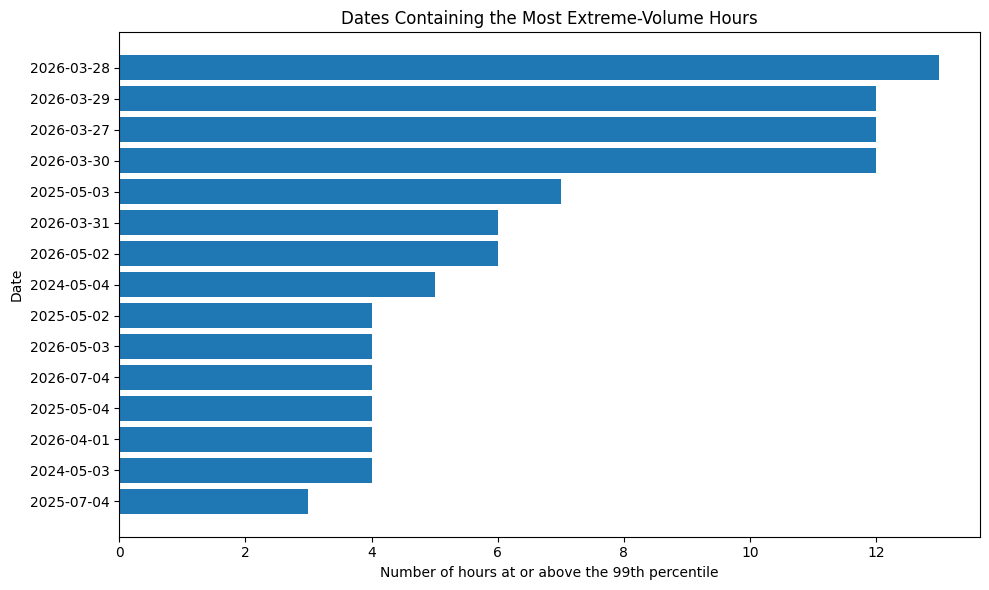

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/extreme_volume_dates.png
Figure exists: True


In [19]:
# Identify the most extreme observations
extreme_threshold = eda_df["NEXT_HOUR_CALLS"].quantile(0.99)

extreme_hours_df = (
    eda_df.loc[
        eda_df["NEXT_HOUR_CALLS"] >= extreme_threshold
    ]
    .copy()
)

extreme_hours_df["TARGET_DATE"] = (
    extreme_hours_df["NEXT_TIMESTAMP"].dt.date
)

print("Extreme-volume threshold (99th percentile):", extreme_threshold)
print("Number of extreme hours:", len(extreme_hours_df))

print("\nTop 25 extreme hourly observations:")
display(
    extreme_hours_df[
        [
            "NEXT_TIMESTAMP",
            "NEXT_HOUR_CALLS",
            "TARGET_HOUR",
            "TARGET_DAY_OF_WEEK",
            "SOURCE_YEAR"
        ]
    ]
    .sort_values("NEXT_HOUR_CALLS", ascending=False)
    .head(25)
)

extreme_date_summary = (
    extreme_hours_df
    .groupby("TARGET_DATE")
    .agg(
        extreme_hours=("NEXT_HOUR_CALLS", "size"),
        maximum_hourly_calls=("NEXT_HOUR_CALLS", "max"),
        mean_extreme_calls=("NEXT_HOUR_CALLS", "mean")
    )
    .reset_index()
    .sort_values(
        ["extreme_hours", "maximum_hourly_calls"],
        ascending=False
    )
)

print("\nDates containing the most extreme hours:")
display(extreme_date_summary.head(20).round(2))

# Daily total call volume for context
daily_summary = (
    eda_df
    .assign(
        TARGET_DATE=eda_df["NEXT_TIMESTAMP"].dt.date
    )
    .groupby("TARGET_DATE")
    .agg(
        total_daily_calls=("NEXT_HOUR_CALLS", "sum"),
        maximum_hourly_calls=("NEXT_HOUR_CALLS", "max"),
        mean_hourly_calls=("NEXT_HOUR_CALLS", "mean"),
        observed_hours=("NEXT_HOUR_CALLS", "size")
    )
    .reset_index()
    .sort_values("total_daily_calls", ascending=False)
)

print("\nHighest-volume complete or partial dates:")
display(daily_summary.head(20).round(2))

plt.figure(figsize=(10, 6))

top_extreme_dates = (
    extreme_date_summary
    .head(15)
    .sort_values("extreme_hours")
)

plt.barh(
    top_extreme_dates["TARGET_DATE"].astype(str),
    top_extreme_dates["extreme_hours"]
)

plt.title("Dates Containing the Most Extreme-Volume Hours")
plt.xlabel("Number of hours at or above the 99th percentile")
plt.ylabel("Date")

plt.tight_layout()

extreme_dates_path = os.path.join(
    figures_folder,
    "extreme_volume_dates.png"
)

plt.savefig(
    extreme_dates_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", extreme_dates_path)
print("Figure exists:", os.path.exists(extreme_dates_path))

Target distribution by chronological split:


,SPLIT,observations,mean_calls,median_calls,standard_deviation,minimum,maximum,skewness,HIGH_VOLUME_PERCENT
0,train,14830,30.78,31.0,12.14,2,101,0.32,5.34
1,validation,3624,28.20,29.0,11.16,2,79,0.18,2.70
2,test,2782,31.82,31.0,15.15,4,166,1.50,8.95


/tmp/ipykernel_1874/1750828510.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


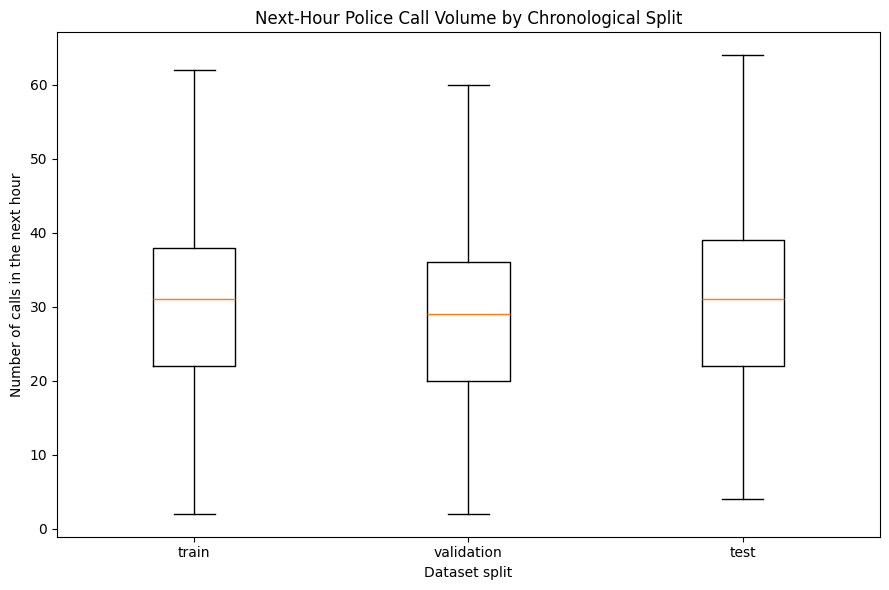

Figure saved: /content/drive/MyDrive/CS171_Police_Call_Project/figures/target_distribution_by_split.png
Figure exists: True


In [20]:
split_order = ["train", "validation", "test"]

split_target_summary = (
    eda_df
    .groupby("SPLIT")["NEXT_HOUR_CALLS"]
    .agg(
        observations="count",
        mean_calls="mean",
        median_calls="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
        skewness="skew"
    )
    .reindex(split_order)
    .reset_index()
)

split_target_summary["HIGH_VOLUME_PERCENT"] = [
    (
        eda_df.loc[
            eda_df["SPLIT"] == split,
            "NEXT_HOUR_CALLS"
        ] >= high_volume_threshold
    ).mean() * 100
    for split in split_order
]

print("Target distribution by chronological split:")
display(split_target_summary.round(2))

plt.figure(figsize=(9, 6))

plt.boxplot(
    [
        eda_df.loc[
            eda_df["SPLIT"] == split,
            "NEXT_HOUR_CALLS"
        ]
        for split in split_order
    ],
    labels=split_order,
    showfliers=False
)

plt.title(
    "Next-Hour Police Call Volume by Chronological Split"
)

plt.xlabel("Dataset split")
plt.ylabel("Number of calls in the next hour")

plt.tight_layout()

split_distribution_path = os.path.join(
    figures_folder,
    "target_distribution_by_split.png"
)

plt.savefig(
    split_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", split_distribution_path)
print(
    "Figure exists:",
    os.path.exists(split_distribution_path)
)

## Exploratory Data Analysis Conclusions

The next-hour police-call target is moderately right-skewed, with a mean of 30.47 calls, a median of 31 calls, and a 95th-percentile high-volume threshold of 50 calls.

Call volume follows strong temporal patterns. Demand is lowest around 5:00 a.m. and generally rises throughout the day, reaching its highest average near 10:00 p.m. Saturday has the highest average call volume, while Wednesday has the lowest. The highest weekday-hour combination is Saturday at 10:00 p.m.

Average call volume is broadly similar across 2024, 2025, and 2026 when equivalent calendar periods are compared. March observations have incomplete coverage because rows requiring complete historical lag features were removed after time-series gaps. Therefore, monthly comparisons were restricted to month-year groups with at least 90% coverage.

Priority 2 and Priority 3 incidents make up most recorded calls. Vehicle stops, disturbances, welfare checks, and audible alarms are the most frequent explicitly modeled call types.

Historical call-volume features are strongly related to the forecasting target. LAG_1H has the strongest Pearson correlation with next-hour volume, followed by LAG_168H and LAG_24H, demonstrating substantial hourly, weekly, and daily persistence.

High-volume hours occur mainly during the evening, particularly around 10:00 p.m. Several extreme observations occurred from March 27 through March 31, 2026. These observations form a sustained unusual period and should not be assigned a cause without additional evidence.

The chronological test period has greater variability, stronger right skew, and a larger proportion of high-volume hours than the training and validation periods. Model evaluation must therefore consider performance during both ordinary and unusually high-demand hours.